# Stage 5 — Demand Forecasting v2 (cyclical features + log target + GRID SEARCH)

v1 was fine (MAE ~34 rides, ~58% better than persistence) but the absolute numbers look big only because
`cnt` ranges 0→~977. v2 squeezes the metrics: **cyclical** hr/weekday/month (sin/cos), optional **log1p(cnt)**
target, and a **grid search** over (hidden, layers, lr, window) picked by validation MAE, then retrains the
best. Leakage-free **chronological** split. `Runtime ▸ GPU ▸ Run all` → downloads `demand_brain.zip` (best model).

In [1]:
import numpy as np, pandas as pd, requests, zipfile, io, json, pickle, os, itertools, torch
import torch.nn as nn; from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler; import matplotlib.pyplot as plt
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'; print('device',DEVICE)
SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)
USE_LOG=True   # predict log1p(cnt) -> reduces right-skew, usually better MAPE

device cuda


In [2]:
url='https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip'
df=pd.read_csv(zipfile.ZipFile(io.BytesIO(requests.get(url).content)).open('hour.csv')).sort_values('instant').reset_index(drop=True)
# Cyclical time encodings (raw hr 0-23 is bad for an LSTM).
df['hr_sin']=np.sin(2*np.pi*df['hr']/24);   df['hr_cos']=np.cos(2*np.pi*df['hr']/24)
df['wd_sin']=np.sin(2*np.pi*df['weekday']/7);df['wd_cos']=np.cos(2*np.pi*df['weekday']/7)
df['mo_sin']=np.sin(2*np.pi*df['mnth']/12);  df['mo_cos']=np.cos(2*np.pi*df['mnth']/12)
TARGET_RAW=df['cnt'].values.astype('float32')  # keep original cnt for baselines/eval
df['target']=np.log1p(df['cnt']) if USE_LOG else df['cnt']
# col 0 MUST be the target column; rest are covariates. Drop casual/registered (=> cnt; leakage).
FEATURES=['target','temp','atemp','hum','windspeed','hr_sin','hr_cos','wd_sin','wd_cos','mo_sin','mo_cos','workingday','holiday','weathersit','season']
DATA=df[FEATURES].values.astype('float32')
print('rows',len(DATA),'| features',len(FEATURES),'| USE_LOG',USE_LOG)

rows 17379 | features 15 | USE_LOG True


In [3]:
n=len(DATA); TR=int(0.70*n); VA=int(0.85*n)  # chronological
def make_data(window):
    sc=StandardScaler().fit(DATA[:TR]); S=sc.transform(DATA).astype('float32')
    m0,s0=float(sc.mean_[0]),float(sc.scale_[0])
    def inv(scaled):  # scaled target -> original cnt
        v=scaled*s0+m0; return np.expm1(v) if USE_LOG else v
    def win(lo,hi):
        X=[];y=[];raw=[];per=[];sea=[]
        for e in range(lo+window,hi):
            X.append(S[e-window:e]); y.append(S[e,0]); raw.append(TARGET_RAW[e])
            per.append(TARGET_RAW[e-1]); sea.append(TARGET_RAW[e-24] if e-24>=0 else TARGET_RAW[e-1])
        return np.array(X,'float32'),np.array(y,'float32'),np.array(raw,'float32'),np.array(per,'float32'),np.array(sea,'float32')
    tr=win(0,TR); va=win(TR,VA); te=win(VA,n)
    return tr,va,te,inv,sc

In [4]:
class DemandLSTM(nn.Module):
    def __init__(self,d,hidden,layers,dropout=0.2):
        super().__init__()
        self.lstm=nn.LSTM(d,hidden,num_layers=layers,batch_first=True,dropout=dropout if layers>1 else 0.0)
        self.head=nn.Linear(hidden,1)
    def forward(self,x): h,_=self.lstm(x); return self.head(h[:,-1,:]).squeeze(-1)
def train_eval(cfg, epochs, patience):
    (Xtr,ytr,_,_,_),(Xva,yva,_,_,_),te,inv,sc=make_data(cfg['window'])
    tr=DataLoader(TensorDataset(torch.tensor(Xtr),torch.tensor(ytr)),batch_size=128,shuffle=True)
    model=DemandLSTM(Xtr.shape[2],cfg['hidden'],cfg['layers'],cfg['dropout']).to(DEVICE)
    opt=torch.optim.Adam(model.parameters(),lr=cfg['lr'],weight_decay=1e-5); crit=nn.L1Loss()
    def vmae():
        model.eval()
        with torch.no_grad(): p=model(torch.tensor(Xva).to(DEVICE)).cpu().numpy()
        return float(np.mean(np.abs(inv(p)-inv(yva))))
    best,bs,bad=1e18,None,0
    for ep in range(epochs):
        model.train()
        for xb,yb in tr: opt.zero_grad(); l=crit(model(xb.to(DEVICE)),yb.to(DEVICE)); l.backward(); opt.step()
        m=vmae()
        if m<best-1e-6: best,bs,bad=m,{k:v.cpu().clone() for k,v in model.state_dict().items()},0
        else:
            bad+=1
            if bad>=patience: break
    model.load_state_dict(bs); return model,best,te,inv,sc

In [5]:
# GRID SEARCH (coarse training per config; best by val MAE)
grid=[dict(hidden=h,layers=L,lr=lr,window=w,dropout=0.2)
      for h in (64,128) for L in (1,2) for lr in (1e-3,5e-4) for w in (24,48)]
print(f'{len(grid)} configs')
results=[]
for i,cfg in enumerate(grid):
    _,vm,_,_,_=train_eval(cfg, epochs=25, patience=5)
    results.append((vm,cfg)); print(f'[{i+1}/{len(grid)}] val_MAE {vm:7.2f}  {cfg}')
results.sort(key=lambda r:r[0]); best_cfg=results[0][1]
print('\nBEST config (val MAE %.2f):'%results[0][0], best_cfg)

16 configs
[1/16] val_MAE   35.52  {'hidden': 64, 'layers': 1, 'lr': 0.001, 'window': 24, 'dropout': 0.2}
[2/16] val_MAE   37.26  {'hidden': 64, 'layers': 1, 'lr': 0.001, 'window': 48, 'dropout': 0.2}
[3/16] val_MAE   39.13  {'hidden': 64, 'layers': 1, 'lr': 0.0005, 'window': 24, 'dropout': 0.2}
[4/16] val_MAE   38.07  {'hidden': 64, 'layers': 1, 'lr': 0.0005, 'window': 48, 'dropout': 0.2}
[5/16] val_MAE   35.87  {'hidden': 64, 'layers': 2, 'lr': 0.001, 'window': 24, 'dropout': 0.2}
[6/16] val_MAE   42.86  {'hidden': 64, 'layers': 2, 'lr': 0.001, 'window': 48, 'dropout': 0.2}
[7/16] val_MAE   48.69  {'hidden': 64, 'layers': 2, 'lr': 0.0005, 'window': 24, 'dropout': 0.2}
[8/16] val_MAE   38.61  {'hidden': 64, 'layers': 2, 'lr': 0.0005, 'window': 48, 'dropout': 0.2}
[9/16] val_MAE   41.95  {'hidden': 128, 'layers': 1, 'lr': 0.001, 'window': 24, 'dropout': 0.2}
[10/16] val_MAE   39.47  {'hidden': 128, 'layers': 1, 'lr': 0.001, 'window': 48, 'dropout': 0.2}
[11/16] val_MAE   33.76  {'hidde

{
  "model": {
    "MAE": 32.90931701660156,
    "RMSE": 52.36858367919922,
    "MAPE": 21.0495548248291
  },
  "persistence_MAE": 80.90050506591797,
  "seasonal_naive_MAE": 81.09794616699219
}
improvement over persistence (MAE): 59.3%  (v1 was ~58%)


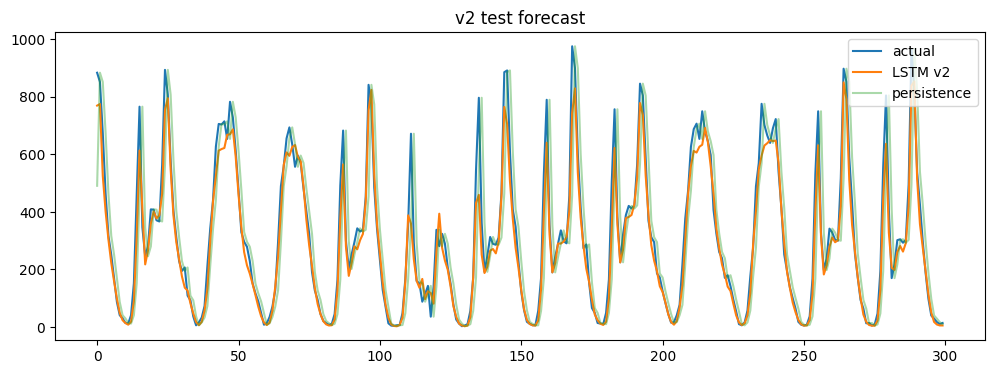

In [6]:
# Retrain the best config longer, then evaluate on the held-out (latest) test period
model,vm,(Xte,yte,yte_raw,persist_te,season_te),inv,scaler=train_eval(best_cfg, epochs=120, patience=12)
model.eval()
with torch.no_grad(): pte=inv(model(torch.tensor(Xte).to(DEVICE)).cpu().numpy())
def mae(a,b): return float(np.mean(np.abs(a-b)))
def rmse(a,b): return float(np.sqrt(np.mean((a-b)**2)))
def mape(a,b): m=b>1; return float(np.mean(np.abs((a[m]-b[m])/b[m]))*100)
M={'model':{'MAE':mae(pte,yte_raw),'RMSE':rmse(pte,yte_raw),'MAPE':mape(pte,yte_raw)},
   'persistence_MAE':mae(persist_te,yte_raw),'seasonal_naive_MAE':mae(season_te,yte_raw)}
imp=100*(M['persistence_MAE']-M['model']['MAE'])/M['persistence_MAE']
print(json.dumps(M,indent=2)); print(f'improvement over persistence (MAE): {imp:.1f}%  (v1 was ~58%)')
plt.figure(figsize=(12,4)); plt.plot(yte_raw[:300],label='actual'); plt.plot(pte[:300],label='LSTM v2'); plt.plot(persist_te[:300],label='persistence',alpha=.4); plt.legend(); plt.title('v2 test forecast'); plt.show()

In [7]:
os.makedirs('brain',exist_ok=True)
torch.save(model.state_dict(),'brain/demand_forecaster.pt')
pickle.dump(scaler,open('brain/scaler.pkl','wb'))
meta={'arch':'LSTM','input_dim':len(FEATURES),'features':FEATURES,'use_log':USE_LOG,**best_cfg,
      'cnt_col':0,'scaler_mean':scaler.mean_.tolist(),'scaler_scale':scaler.scale_.tolist()}
json.dump(meta,open('brain/model_meta.json','w'),indent=2)
metrics={'mae':round(M['model']['MAE'],3),'rmse':round(M['model']['RMSE'],3),'mape':round(M['model']['MAPE'],3),
         'persistence_mae':round(M['persistence_MAE'],3),'seasonal_naive_mae':round(M['seasonal_naive_MAE'],3),
         'improvement_over_persistence_pct':round(imp,2),'best_config':best_cfg,'use_log':USE_LOG,
         'dataset':'UCI Bike Sharing #275 (v2: cyclical+log+gridsearch, chronological split, no leakage)'}
json.dump(metrics,open('brain/metrics.json','w'),indent=2)
with zipfile.ZipFile('demand_brain.zip','w',zipfile.ZIP_DEFLATED) as zz:
    for fn in ['demand_forecaster.pt','scaler.pkl','model_meta.json','metrics.json']: zz.write('brain/'+fn,fn)
print(json.dumps(metrics,indent=2))
try:
    from google.colab import files; files.download('demand_brain.zip')
except Exception as e: print('grab demand_brain.zip from the file browser', e)

{
  "mae": 32.909,
  "rmse": 52.369,
  "mape": 21.05,
  "persistence_mae": 80.901,
  "seasonal_naive_mae": 81.098,
  "improvement_over_persistence_pct": 59.32,
  "best_config": {
    "hidden": 128,
    "layers": 1,
    "lr": 0.0005,
    "window": 24,
    "dropout": 0.2
  },
  "use_log": true,
  "dataset": "UCI Bike Sharing #275 (v2: cyclical+log+gridsearch, chronological split, no leakage)"
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
**What to look for:** v2 should improve **MAPE** and **MAE** vs v1 (MAE 33.9 / MAPE 23.4%) and keep beating
persistence. If it does, send `demand_brain.zip` and I'll wire it + close Stage 5. If a config is clearly best,
I can widen the grid around it next.